In [2]:
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import torch
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns


import matplotlib
plt.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['font.family'] = 'arial'
matplotlib.rcParams["legend.handletextpad"] = 0.
matplotlib.rcParams["legend.labelspacing"] = .3
pltkw = dict(bbox_inches='tight', transparent=True)

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

C:\Users\lshh\AppData\Local\Temp\ipykernel_76564\2119909225.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_lower_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].min()
C:\Users\lshh\AppData\Local\Temp\ipykernel_76564\2119909225.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_upper_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].max()
C:\Users\lshh\AppData\Local\Temp\ipykernel_76564\2119909225.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{pos:.0%}' for pos in a

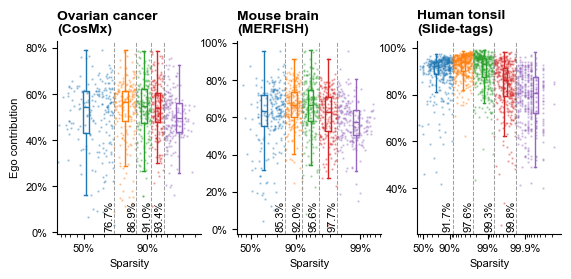

In [43]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(6.5, 2.5))
gs = GridSpec(1, 3, hspace=0., wspace=.25, figure=fig)
axes = [fig.add_subplot(gs[0, 0]), 
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2])]

xlabel = 'Sparsity'

###################################################################################################
#                                HGSC                                                             #
###################################################################################################

ax = axes[0]

contrib_df = pd.read_csv('saved_results/hgsc_contrib_insp.csv', index_col=0)
contrib_df['sparsity_rank'] = contrib_df['sparsity'].rank()
contrib_df['sparsity_bin'] = pd.cut(contrib_df['sparsity_rank'], bins=5)
bin_lower_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].min()
bin_upper_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].max()

for bin in contrib_df['sparsity_bin'].cat.categories:
    bin_data = contrib_df[contrib_df['sparsity_bin'] == bin]
    ax.scatter(1 - bin_data['sparsity'], bin_data['ego_pct'], s=0.5, label=f'{bin.left:.2f}-{bin.right:.2f}', alpha=0.33)

ax.set_xscale('log')

bin_data = []
bin_positions = []
bin_widths = []
bin_left_sparsitys = []
bin_right_sparsitys = []
for bin in contrib_df['sparsity_bin'].cat.categories:
    bin_data.append(contrib_df[contrib_df['sparsity_bin'] == bin]['ego_pct'])
    bin_left_sparsitys.append(contrib_df[contrib_df['sparsity_bin'] == bin]['sparsity'].min())
    bin_right_sparsitys.append(contrib_df[contrib_df['sparsity_bin'] == bin]['sparsity'].max())
    bin_positions.append(np.sqrt((1 - bin_left_sparsitys[-1]) * np.maximum(0.0001, (1 - bin_right_sparsitys[-1]))))
    bin_widths.append(bin_positions[-1] * 0.15)

boxplot = ax.boxplot(bin_data, positions=bin_positions, widths=bin_widths, showfliers=False, 
           boxprops=dict(color='red'), 
           whiskerprops=dict(color='red'), 
           capprops=dict(color='red'), 
           medianprops=dict(color='red'))

for i, (left, right) in enumerate(zip(bin_left_sparsitys, bin_right_sparsitys)):
    if i > 0:
        ax.axvline(1 - left, color='gray', linestyle='--', alpha=0.75, lw=.75)
        ax.text((1 - left) * 0.975, ax.get_ylim()[0] + 0.01, f'{left:.1%}', rotation=90, ha='left', va='bottom', rotation_mode='anchor', fontsize=8)

for i, patch in enumerate(boxplot['boxes']):
    patch.set(color = f'C{i}')

for i, patch in enumerate(boxplot['whiskers']):
    patch.set(color = f'C{i // 2}')

for i, patch in enumerate(boxplot['caps']):
   patch.set(color = f'C{i // 2}')

for i, patch in enumerate(boxplot['medians']):
    patch.set(color = f'C{i}')

ax.set_xlim(ax.get_xlim()[1], ax.get_xlim()[0])
ax.set_xticks([0.1, 0.5])
ax.set_xticklabels([f'{100 - pos*100:1g}%' for pos in ax.get_xticks()], size=8)
ax.set_yticklabels([f'{pos:.0%}' for pos in ax.get_yticks()], size=8)
ax.set_xlabel(xlabel, size=8)
ax.set_ylabel('Ego contribution', size=8)

ax.set_title('Ovarian cancer\n(CosMx)', loc='left', weight='bold', size=10)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

###################################################################################################
#                                Mouse Brain                                                      #
###################################################################################################

ax = axes[1]
contrib_df = pd.read_csv('saved_results/mouse_brain_contrib_insp.csv', index_col=0)
contrib_df['sparsity_rank'] = contrib_df['sparsity'].rank()
contrib_df['sparsity_bin'] = pd.cut(contrib_df['sparsity_rank'], bins=5)
bin_lower_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].min()
bin_upper_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].max()

for bin in contrib_df['sparsity_bin'].cat.categories:
    bin_data = contrib_df[contrib_df['sparsity_bin'] == bin]
    ax.scatter(1 - bin_data['sparsity'], bin_data['ego_pct'], s=0.5, label=f'{bin.left:.2f}-{bin.right:.2f}', alpha=0.33)

ax.set_xscale('log')

bin_data = []
bin_positions = []
bin_widths = []
bin_left_sparsitys = []
bin_right_sparsitys = []
for bin in contrib_df['sparsity_bin'].cat.categories:
    bin_data.append(contrib_df[contrib_df['sparsity_bin'] == bin]['ego_pct'])
    bin_left_sparsitys.append(contrib_df[contrib_df['sparsity_bin'] == bin]['sparsity'].min())
    bin_right_sparsitys.append(contrib_df[contrib_df['sparsity_bin'] == bin]['sparsity'].max())
    bin_positions.append(np.sqrt((1 - bin_left_sparsitys[-1]) * np.maximum(0.0001, (1 - bin_right_sparsitys[-1]))))
    bin_widths.append(bin_positions[-1] * 0.2)

boxplot = ax.boxplot(bin_data, positions=bin_positions, widths=bin_widths, showfliers=False, 
           boxprops=dict(color='red'), 
           whiskerprops=dict(color='red'), 
           capprops=dict(color='red'), 
           medianprops=dict(color='red'))

for i, (left, right) in enumerate(zip(bin_left_sparsitys, bin_right_sparsitys)):
    if i > 0:
        ax.axvline(1 - left, color='gray', linestyle='--', alpha=0.75, lw=.75)
        ax.text(1 - left, ax.get_ylim()[0] + 0.01, f'{left:.1%}', rotation=90, ha='left', va='bottom', rotation_mode='anchor', fontsize=8)

for i, patch in enumerate(boxplot['boxes']):
    patch.set(color = f'C{i}')

for i, patch in enumerate(boxplot['whiskers']):
    patch.set(color = f'C{i // 2}')

for i, patch in enumerate(boxplot['caps']):
   patch.set(color = f'C{i // 2}')

for i, patch in enumerate(boxplot['medians']):
    patch.set(color = f'C{i}')

ax.set_xlim(ax.get_xlim()[1], ax.get_xlim()[0])

ax.set_xticks([0.01, 0.1, 0.5])
ax.set_xticklabels([f'{100 - pos*100:1g}%' for pos in ax.get_xticks()], size=8)
ax.set_yticklabels([f'{pos:.0%}' for pos in ax.get_yticks()], size=8)
ax.set_xlabel(xlabel, size=8)

ax.set_title('Mouse brain\n(MERFISH)', loc='left', weight='bold', size=10)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

###################################################################################################
#                                Human tonsil (Slide-tags)                                        #
###################################################################################################
ax = axes[2]

contrib_df = pd.read_csv('saved_results/slidetags_contrib_insp.csv', index_col=0)

contrib_df['sparsity_rank'] = contrib_df['sparsity'].rank()
contrib_df['sparsity_bin'] = pd.cut(contrib_df['sparsity_rank'], bins=5)
bin_lower_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].min()
bin_upper_sparsity = contrib_df.groupby('sparsity_bin')['sparsity'].max()

for bin in contrib_df['sparsity_bin'].cat.categories:
    bin_data = contrib_df[contrib_df['sparsity_bin'] == bin]
    ax.scatter(1 - bin_data['sparsity'], bin_data['ego_pct'], s=0.5, label=f'{bin.left:.2f}-{bin.right:.2f}', alpha=0.33)

ax.set_xscale('log')

bin_data = []
bin_positions = []
bin_widths = []
bin_left_sparsitys = []
bin_right_sparsitys = []
for bin in contrib_df['sparsity_bin'].cat.categories:
    bin_data.append(contrib_df[contrib_df['sparsity_bin'] == bin]['ego_pct'])
    bin_left_sparsitys.append(contrib_df[contrib_df['sparsity_bin'] == bin]['sparsity'].min())
    bin_right_sparsitys.append(contrib_df[contrib_df['sparsity_bin'] == bin]['sparsity'].max())
    bin_positions.append(np.sqrt((1 - bin_left_sparsitys[-1]) * np.maximum(0.0001, (1 - bin_right_sparsitys[-1]))))
    bin_widths.append(bin_positions[-1] * 0.25)

boxplot = ax.boxplot(bin_data, positions=bin_positions, widths=bin_widths, showfliers=False, 
           boxprops=dict(color='red'), 
           whiskerprops=dict(color='red'), 
           capprops=dict(color='red'), 
           medianprops=dict(color='red'))

for i, (left, right) in enumerate(zip(bin_left_sparsitys, bin_right_sparsitys)):
    if i > 0:
        ax.axvline(1 - left, color='gray', linestyle='--', alpha=0.75, lw=.75)
        ax.text(1 - left, ax.get_ylim()[0] + 0.01, f'{left:.1%}', rotation=90, ha='left', va='bottom', rotation_mode='anchor', fontsize=8)

for i, patch in enumerate(boxplot['boxes']):
    patch.set(color = f'C{i}')

for i, patch in enumerate(boxplot['whiskers']):
    patch.set(color = f'C{i // 2}')

for i, patch in enumerate(boxplot['caps']):
   patch.set(color = f'C{i // 2}')

for i, patch in enumerate(boxplot['medians']):
    patch.set(color = f'C{i}')

ax.set_xlabel(xlabel, size=8)
# ax.set_ylim(ax.get_ylim()[0], 1.02)
ax.set_xlim(ax.get_xlim()[1], ax.get_xlim()[0])
ax.set_xticks([0.001, 0.01, 0.1, 0.5])
ax.set_xticklabels([f'{100 - pos*100:1g}%' for pos in ax.get_xticks()], size=8)
ax.set_yticklabels([f'{pos:.0%}' for pos in ax.get_yticks()], size=8)

ax.set_title('Human tonsil\n(Slide-tags)', loc='left', weight='bold', size=10)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

fig.align_xlabels()

fig.savefig('figures2/contrib_insp.pdf', **pltkw)